# Imports & HelperFuncs

In [15]:
from testFuncs import load_dataset_df
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
base_path = base_img_path = "../memoriaLatex"

In [3]:
from pathlib import Path
from functools import lru_cache

@lru_cache
def n_instances(ds, dataset_root=Path("dataset")):
    return load_dataset_df(
        dataset=ds,
        noise_type="data_base",
        split="cc",
        encoding=None,
        root=dataset_root,
    ).shape[0]

def get_available_datasets(dataset_root=Path("dataset"), n=None, reverse=False):
    base_dir = dataset_root / "data_base"
    datasets = sorted(
        [p.name for p in base_dir.iterdir() if p.is_dir()],
        key=lambda ds: (n_instances(ds, dataset_root), ds),
        reverse=reverse,
    )
    return datasets if n is None else datasets[:n]
    
keel_datasets = get_available_datasets(Path("dataset"), n=30)
print(keel_datasets)

['zoo', 'hayes-roth', 'lymphography', 'iris', 'autos', 'wine', 'sonar', 'glass', 'newthyroid', 'heart', 'cleveland', 'splice', 'ecoli', 'ionosphere', 'dermatology', 'monk-2', 'led7digit', 'wdbc', 'balance', 'pima', 'vehicle', 'vowel', 'german', 'flare', 'nursery', 'contraceptive', 'yeast', 'car', 'shuttle', 'segment']


# Simulations

In [210]:
import numpy as np

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm

from filters import *
from filters.noiseScoreFiltering import NoiseScoreFilter




# Classifier base.
# clf = DecisionTreeClassifier(
#         criterion="entropy",
#         splitter="best",
#         random_state=33
#     )
clf = RandomForestClassifier()

# Fixed dataset loading config.
fixed_dataset_info = {
    "noise_type": "cla_rand",
    "seed": 1,
    "encoding": "onehot",
}


base_estimators = [
    ("DT", DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        random_state=33
    )),

    ("KNN1", KNeighborsClassifier(
        n_neighbors=3
    )),

    ("LR", LogisticRegression(
        max_iter=1000,
        random_state=33
    )),

    ("GNB", GaussianNB()),

    ("DT_SMALL", DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=5,
        min_samples_leaf=2,
        random_state=33
    )),

    ("SGD_LOG", SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        tol=1e-3,
        random_state=33
    )),
]

# Base filters that expose noise_score_.
base_filters = {
    "ENN": ENNFilter(n_neighbors=9, action="detect"),
    "ENNProb": ENNProbFilter(n_neighbors=9, action="detect"),
    "NCNEdit": NCNEdit(n_neighbors=9, action="detect"),
    "EF" : EnsembleFiltering(
                estimators=[est for _, est in base_estimators],
                cv=10,
                mode="threshold",
                threshold = 0.8,
                action="remove",
                random_state=33,
            )
}

# Noise-score-based filters.
noiseScore_filters = {
    "NSFilter_mean_": NoiseScoreFilter(threshold="mean"),
    "NSFilter_adaptative": NoiseScoreFilter(threshold="adaptative"),
    "NSFilter_rat_valley": NoiseScoreFilter(threshold="rational_valley"),
    "NSFilter_th_0.3": NoiseScoreFilter(threshold=0.3),
    "NSFilter_th_0.5": NoiseScoreFilter(threshold=0.5),
    "NSFilter_th_0.7": NoiseScoreFilter(threshold=0.7),
    "NSFilter_quant_0.5": NoiseScoreFilter(threshold="quantile", quantile=0.5),
    "NSFilter_quant_0.75": NoiseScoreFilter(threshold="quantile", quantile=0.7),
    "NSFilter_quant_0.95": NoiseScoreFilter(threshold="quantile", quantile=0.99),
}

def make_sample_weights(noise_scores, kind="linear", alpha=1.0):
    scores = np.asarray(noise_scores, dtype=float)
    scores = np.clip(scores, 0.0, 1.0)

    if kind == "linear":
        weights = 1.0 - scores
    elif kind == "exp":
        weights = np.exp(-alpha * scores)
    else:
        raise ValueError("kind must be 'linear' or 'exp'")

    weights = np.clip(weights, 1e-3, None)
    weights = weights / weights.mean()
    return weights

results = {
    "dataset_id": [],
    "fold_id": [],
    "filter_id": [],
    "noise_k": [],
    "bal_acc": [],
}

for noise_k in [5, 25, 50]:
    for dataset in tqdm(keel_datasets[:30]):
        for base_filter_name, base_filter in base_filters.items():
            for fold_idx in range(1, 6):
                train_fold_ds = load_dataset_df(
                    dataset=dataset,
                    split="tra",
                    fold=fold_idx,
                    k=noise_k,
                    **fixed_dataset_info,
                )
                test_fold_ds = load_dataset_df(
                    dataset=dataset,
                    split="tst",
                    fold=fold_idx,
                    k=noise_k,
                    **fixed_dataset_info,
                )

                X_tr = train_fold_ds.iloc[:, :-1]
                y_tr = train_fold_ds.iloc[:, -1]
                X_ts = test_fold_ds.iloc[:, :-1]
                y_ts = test_fold_ds.iloc[:, -1]

                X_tr_np = X_tr.to_numpy()
                X_ts_np = X_ts.to_numpy()
                y_tr_np = y_tr.to_numpy() if hasattr(y_tr, "to_numpy") else np.asarray(y_tr)
                y_ts_np = y_ts.to_numpy() if hasattr(y_ts, "to_numpy") else np.asarray(y_ts)

                # Scale before filtering.
                sc = StandardScaler()
                X_tr_sc = sc.fit_transform(X_tr_np)
                X_ts_sc = sc.transform(X_ts_np)

                # 1) Baseline without filtering.
                model = clone(clf)
                model.fit(X_tr_sc, y_tr_np)

                results["dataset_id"].append(dataset)
                results["fold_id"].append(fold_idx)
                results["filter_id"].append("None")
                results["noise_k"].append(noise_k)
                results["bal_acc"].append(
                    balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                )

                # 2) Fit the base filter on scaled data and train only on kept samples.
                fitted_base_filter = clone(base_filter)
                fitted_base_filter.fit(X_tr_sc, y_tr_np)
                keep_mask = fitted_base_filter.result_.keep_mask

                X_tr_kept = X_tr_sc[keep_mask]
                y_tr_kept = y_tr_np[keep_mask]

                if np.unique(y_tr_kept).size < 2:
                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["filter_id"].append(base_filter_name)
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(np.nan)
                else:
                    model = clone(clf)
                    model.fit(X_tr_kept, y_tr_kept)

                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["filter_id"].append(base_filter_name)
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(
                        balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                    )

                # 3) Weighted training on scaled data.
                weights_linear = make_sample_weights(
                    fitted_base_filter.noise_score_,
                    kind="linear",
                )

                model = clone(clf)
                model.fit(X_tr_sc, y_tr_np, sample_weight=weights_linear)

                results["dataset_id"].append(dataset)
                results["fold_id"].append(fold_idx)
                results["filter_id"].append(f"{base_filter_name}_weight_linear")
                results["noise_k"].append(noise_k)
                results["bal_acc"].append(
                    balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                )

                weights_exp = make_sample_weights(
                    fitted_base_filter.noise_score_,
                    kind="exp",
                    alpha=1.0,
                )

                model = clone(clf)
                model.fit(X_tr_sc, y_tr_np, sample_weight=weights_exp)

                results["dataset_id"].append(dataset)
                results["fold_id"].append(fold_idx)
                results["filter_id"].append(f"{base_filter_name}_weight_exp")
                results["noise_k"].append(noise_k)
                results["bal_acc"].append(
                    balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                )

                # 4) Noise-score filters on scaled data.
                for nsf_name, nsf in noiseScore_filters.items():
                    fitted_nsf = nsf
                    fitted_nsf.noise_scores = fitted_base_filter.noise_score_
                    X_tr_f, y_tr_f = fitted_nsf.fit_resample(X_tr_sc, y_tr_np)

                    if np.unique(y_tr_f).size < 2:
                        results["dataset_id"].append(dataset)
                        results["fold_id"].append(fold_idx)
                        results["filter_id"].append(f"{base_filter_name}_{nsf_name}")
                        results["noise_k"].append(noise_k)
                        results["bal_acc"].append(np.nan)
                        continue

                    model = clone(clf)
                    model.fit(X_tr_f, y_tr_f)

                    results["dataset_id"].append(dataset)
                    results["fold_id"].append(fold_idx)
                    results["filter_id"].append(f"{base_filter_name}_{nsf_name}")
                    results["noise_k"].append(noise_k)
                    results["bal_acc"].append(
                        balanced_accuracy_score(y_ts_np, model.predict(X_ts_sc))
                    )

  0%|          | 0/30 [00:00<?, ?it/s]

/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=10.
  warnings.warn(
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class 

  0%|          | 0/30 [00:00<?, ?it/s]

/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y h

  0%|          | 0/30 [00:00<?, ?it/s]

/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in

In [4]:
import pickle
# pickle.dump(results, open("./results/res_prueba_ns_based_rf.pkl", "wb"))
results_rf = pickle.load(open("./results/res_prueba_ns_based_rf.pkl", "rb"))
results_logReg = pickle.load(open("./results/res_prueba_ns_based.pkl", "rb"))
results_dt = pickle.load(open("./results/res_prueba_ns_based_dt.pkl", "rb"))


In [8]:
r1 = pd.DataFrame(results_rf)
r2 = pd.DataFrame(results_logReg)
r3 = pd.DataFrame(results_dt)

r1 = r1[(r1.filter_id=="None")].rename({"bal_acc":"rf_bal_acc"},axis=1)
r2 = r2[(r2.filter_id=="None")].rename({"bal_acc":"logReg_bal_acc"},axis=1)
r3 = r3[(r3.filter_id=="None")].rename({"bal_acc":"dt_bal_acc"},axis=1)
out = r1.merge(r2, on=["dataset_id","fold_id","filter_id","noise_k"])
out = out.merge(r3, on=["dataset_id","fold_id","filter_id","noise_k"])
# out["bal_acc_dif"]= out.rf_bal_acc-out.logReg_bal_acc
out2 = out.drop("fold_id", axis=1).groupby(["dataset_id", "filter_id", "noise_k"]).mean().reset_index()
out2

,dataset_id,filter_id,noise_k,rf_bal_acc,logReg_bal_acc,dt_bal_acc
0,autos,None,5,0.792269,0.706000,0.839296
1,autos,None,25,0.712843,0.651370,0.610741
2,autos,None,50,0.559500,0.461852,0.401000
3,balance,None,5,0.592433,0.632103,0.527397
4,balance,None,25,0.565232,0.629784,0.461866
...,...,...,...,...,...,...
85,yeast,None,25,0.525048,0.500530,0.303974
86,yeast,None,50,0.398144,0.455723,0.234703
87,zoo,None,5,0.907540,0.858730,0.834921
88,zoo,None,25,0.830159,0.698214,0.712897


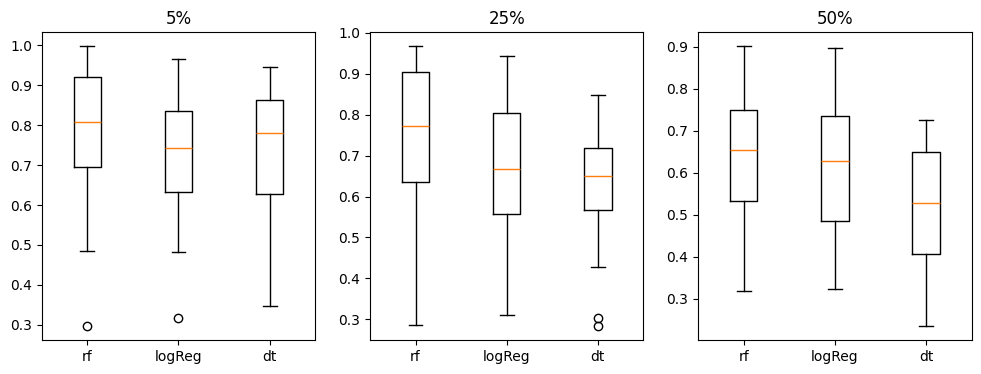

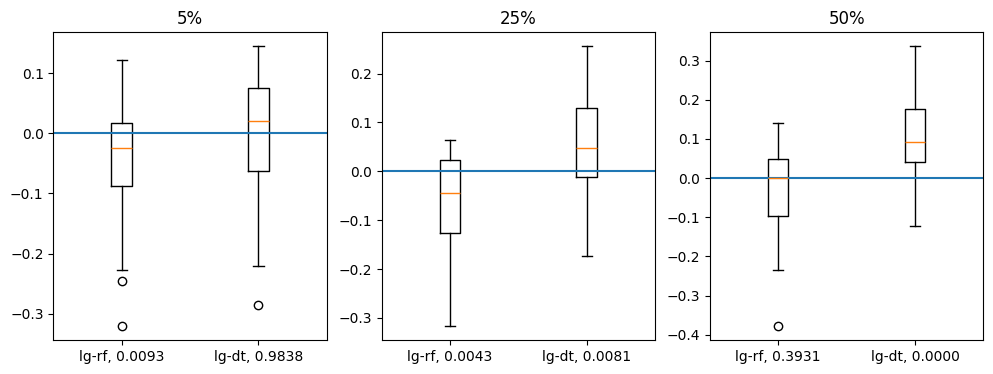

In [18]:
plt.figure(figsize=(12,4))
for i,k in enumerate([5,25,50]):
    plt.subplot(1,3,1+i)
    plt.boxplot([out2[out2.noise_k==k].rf_bal_acc, out2[out2.noise_k==k].logReg_bal_acc, out2[out2.noise_k==k].dt_bal_acc])
    plt.xticks([1,2,3], labels=["rf","logReg", "dt"])
    plt.title(f"{k}%")
plt.show()

plt.figure(figsize=(12,4))
for i,k in enumerate([5,25,50]):
    plt.subplot(1,3,1+i)
    lg_rf = out2[out2.noise_k==k].logReg_bal_acc-out2[out2.noise_k==k].rf_bal_acc
    lg_dt = out2[out2.noise_k==k].logReg_bal_acc-out2[out2.noise_k==k].dt_bal_acc
    plt.boxplot([lg_rf, lg_dt] )
    plt.xticks([1,2], labels=[
        f"lg-rf, {wilcoxon(lg_rf).pvalue:0.4f}",
        f"lg-dt, {wilcoxon(lg_dt).pvalue:0.4f}"])
    plt.hlines([0], xmin=0.5,xmax=2.5)
    plt.title(f"{k}%")
plt.show()

In [22]:
results = pd.DataFrame(results_rf)
results

,dataset_id,fold_id,filter_id,noise_k,bal_acc
0,zoo,1,None,5,0.857143
1,zoo,1,ENN,5,0.642857
2,zoo,1,ENN_weight_linear,5,0.857143
3,zoo,1,ENN_weight_exp,5,0.857143
4,zoo,1,ENN_NSFilter_mean_,5,0.571429
...,...,...,...,...,...
23395,segment,5,EF_NSFilter_th_0.5,50,0.945887
23396,segment,5,EF_NSFilter_th_0.7,50,0.941558
23397,segment,5,EF_NSFilter_quant_0.5,50,0.943723
23398,segment,5,EF_NSFilter_quant_0.75,50,0.932900


In [23]:
from scipy.stats import wilcoxon

res = (
    pd.DataFrame(results)
    .groupby(["dataset_id", "filter_id", "noise_k"])
    .mean(numeric_only=True)
    .drop("fold_id", axis=1, errors="ignore")
    .reset_index()
)

baseline_res = (
    res[res["filter_id"] == "None"]
    .drop(columns=["filter_id"])
    .rename(columns={"bal_acc": "baseline_bal_acc"})
)

res = res.merge(
    baseline_res[["dataset_id", "noise_k", "baseline_bal_acc"]],
    on=["dataset_id", "noise_k"],
    how="left",
)

res["bal_acc_diff"] = (res["bal_acc"] - res["baseline_bal_acc"]) * 100
res["base_filter"] = res["filter_id"].str.split("_").str[0]

out = (
    res[res["filter_id"] != "None"]
    .groupby(["noise_k", "filter_id"], as_index=False)["bal_acc_diff"]
    .mean()
    .sort_values(["noise_k", "bal_acc_diff"], ascending=[True, False])
)

tests = []

for (noise_k, filter_id), g in res[res["filter_id"] != "None"].groupby(["noise_k", "filter_id"]):
    base_filter = g["base_filter"].iloc[0]

    base = res[
        (res["noise_k"] == noise_k) &
        (res["filter_id"] == base_filter)
    ][["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "base_bal_acc"})

    ext = g[["dataset_id", "bal_acc"]].rename(columns={"bal_acc": "ext_bal_acc"})

    aligned = base.merge(ext, on="dataset_id", how="inner").dropna()
    if len(aligned) == 0:
        continue

    stat, p = wilcoxon(
        aligned["ext_bal_acc"]-aligned["base_bal_acc"],
        alternative="greater",
    )

    tests.append({
        "noise_k": noise_k,
        "filter_id": filter_id,
        "p_value": p,
        "wilcoxon_stat": stat,
        "n": len(aligned),
    })

tests_df = pd.DataFrame(tests)

out = out.merge(
    tests_df[["noise_k", "filter_id", "p_value", "wilcoxon_stat", "n"]],
    on=["noise_k", "filter_id"],
    how="left",
)

out["base_filter"] = out["filter_id"].str.split("_").str[0]

tabla = (
    out.pivot_table(
        index=["base_filter", "filter_id"],
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    )
)

tablas = {}
for bf, g in out.groupby("base_filter"):
    orden = (
        g.groupby("filter_id")["bal_acc_diff"]
         .mean()
         .sort_values(ascending=False)
         .index
    )
    tabla = g.pivot_table(
        index="filter_id",
        columns="noise_k",
        values=["bal_acc_diff", "p_value"],
    ).loc[orden]
    tablas[bf] = tabla

for bf, tabla in tablas.items():
    print(f"\n=== {bf} ===")
    display(tabla)

/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: 


=== EF ===


/home/juamp/Documents/Master/.venv/lib/python3.14/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


bal_acc_diff                       p_value            \
noise_k                          5         25        50        5         25   
filter_id                                                                     
EF_NSFilter_th_0.7        -0.880381 -0.290957  3.991490  0.119306  0.043969   
EF_weight_exp              0.668122  0.322723 -0.265872  0.001280  0.144683   
EF                        -1.576544 -1.411655  3.542466       NaN       NaN   
EF_NSFilter_th_0.5        -1.859292 -1.613392  3.617982  0.944004  0.814630   
EF_NSFilter_quant_0.95     0.342991 -0.315094 -0.179487  0.007495  0.403915   
EF_weight_linear          -0.066883 -0.076783 -0.078288  0.043969  0.164235   
EF_NSFilter_quant_0.75    -5.283696 -1.821128  4.205445  0.999994  0.868939   
EF_NSFilter_rat_valley    -4.643723 -2.326112  3.397247  0.999848  0.997626   
EF_NSFilter_mean_         -5.427607 -3.152473  3.848418  0.999828  0.999915   
EF_NSFilter_th_0.3        -4.522757 -3.613874  2.353157  1.000000  0.999993   
EF_NSFilter_adaptative    -6.336511 -4.086047  1.664740  0.999975  0.999996   
EF_NSFilter_quant_0.5     -9.119932 -4.854149  2.916701  1.000000  0.999993   

                                  
noise_k                       50  
filter_id                         
EF_NSFilter_th_0.7      0.459648  
EF_weight_exp           0.999330  
EF                           NaN  
EF_NSFilter_th_0.5      0.205324  
EF_NSFilter_quant_0.95  0.999434  
EF_weight_linear        0.998262  
EF_NSFilter_quant_0.75  0.106872  
EF_NSFilter_rat_valley  0.735447  
EF_NSFilter_mean_       0.234417  
EF_NSFilter_th_0.3      0.976370  
EF_NSFilter_adaptative  0.976370  
EF_NSFilter_quant_0.5   0.814630


=== ENN ===


bal_acc_diff                       p_value            \
noise_k                           5         25        50        5         25   
filter_id                                                                      
ENN_weight_exp              0.231422  0.184797  0.050463  0.000074  0.001872   
ENN_NSFilter_quant_0.95     0.502304 -0.261268 -0.136752  0.000013  0.001184   
ENN_NSFilter_th_0.7        -1.736025  0.000351  1.745624  0.000488  0.000333   
ENN_weight_linear          -0.127736 -0.050673 -0.029225  0.000146  0.001738   
ENN_NSFilter_th_0.5        -4.346514 -2.993987  2.987233  0.001689  0.000019   
ENN_NSFilter_quant_0.75    -8.343721 -3.936482  2.932272  0.730666  0.002169   
ENN_NSFilter_rat_valley    -8.742838 -3.949407  2.279684  0.980539  0.006848   
ENN                        -7.299714 -7.213721 -0.053950       NaN       NaN   
ENN_NSFilter_mean_        -10.804133 -7.190834  2.892950  0.999812  0.675599   
ENN_NSFilter_adaptative   -12.249666 -8.060841  2.459270  0.999986  0.647436   
ENN_NSFilter_th_0.3        -8.931674 -8.650041 -1.924640  0.995283  0.981699   
ENN_NSFilter_quant_0.5    -14.020328 -8.339830  2.338590  0.999998  0.803475   

                                   
noise_k                        50  
filter_id                          
ENN_weight_exp           0.451613  
ENN_NSFilter_quant_0.95  0.508083  
ENN_NSFilter_th_0.7      0.202247  
ENN_weight_linear        0.500000  
ENN_NSFilter_th_0.5      0.001947  
ENN_NSFilter_quant_0.75  0.002691  
ENN_NSFilter_rat_valley  0.001872  
ENN                           NaN  
ENN_NSFilter_mean_       0.000012  
ENN_NSFilter_adaptative  0.000156  
ENN_NSFilter_th_0.3      0.976370  
ENN_NSFilter_quant_0.5   0.000015


=== ENNProb ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
ENNProb_NSFilter_quant_0.95    -0.067519  0.095793  0.474875  0.000142   
ENNProb_weight_linear           0.133638 -0.097939  0.041751  0.000204   
ENNProb_NSFilter_th_0.7        -1.393074 -0.205862  1.462825  0.000114   
ENNProb_weight_exp              0.055337  0.074329 -0.309347  0.000116   
ENNProb_NSFilter_th_0.5        -2.884889 -2.300864  3.235102  0.000113   
ENNProb_NSFilter_rat_valley    -7.446711 -4.047317  2.848060  0.985337   
ENNProb_NSFilter_quant_0.75    -7.679784 -3.927635  2.856990  0.900880   
ENNProb                        -5.269418 -5.186648  1.546667       NaN   
ENNProb_NSFilter_mean_         -9.450680 -6.321347  2.503714  0.999854   
ENNProb_NSFilter_th_0.3        -7.312731 -7.150054 -0.743939  0.998772   
ENNProb_NSFilter_adaptative   -10.516458 -7.833924 -1.159767  0.999069   
ENNProb_NSFilter_quant_0.5    -14.492413 -8.385813  1.797265  0.999996   

                                                 
noise_k                            25        50  
filter_id                                        
ENNProb_NSFilter_quant_0.95  0.002506  0.735447  
ENNProb_weight_linear        0.001094  0.797753  
ENNProb_NSFilter_th_0.7      0.000044  0.532301  
ENNProb_weight_exp           0.001383  0.911404  
ENNProb_NSFilter_th_0.5      0.000040  0.021326  
ENNProb_NSFilter_rat_valley  0.185370  0.040164  
ENNProb_NSFilter_quant_0.75  0.261774  0.122473  
ENNProb                           NaN       NaN  
ENNProb_NSFilter_mean_       0.954025  0.190586  
ENNProb_NSFilter_th_0.3      0.999436  0.998506  
ENNProb_NSFilter_adaptative  0.982496  0.969717  
ENNProb_NSFilter_quant_0.5   0.997083  0.396080


=== NCNEdit ===


bal_acc_diff                       p_value  \
noise_k                               5         25        50        5    
filter_id                                                                
NCNEdit_NSFilter_quant_0.95     0.599758  0.254210  0.144676  0.000016   
NCNEdit_NSFilter_th_0.7        -0.912189 -0.036992  1.735140  0.000050   
NCNEdit_weight_exp              0.360517 -0.230046  0.306917  0.000005   
NCNEdit_weight_linear          -0.062276  0.145830 -0.171862  0.000040   
NCNEdit_NSFilter_th_0.5        -3.266648 -1.513281  3.774115  0.000045   
NCNEdit_NSFilter_quant_0.75    -7.971253 -3.010875  3.291754  0.623063   
NCNEdit_NSFilter_rat_valley    -9.044273 -4.278455  2.842145  0.949801   
NCNEdit                        -6.897878 -5.820507  1.187971       NaN   
NCNEdit_NSFilter_mean_        -10.530414 -5.646170  3.082696  0.989357   
NCNEdit_NSFilter_adaptative   -13.205916 -6.696427  2.495787  0.999984   
NCNEdit_NSFilter_quant_0.5    -12.862880 -7.187069  2.453463  0.999747   
NCNEdit_NSFilter_th_0.3        -9.201830 -7.944956 -2.123428  0.998721   

                                                 
noise_k                            25        50  
filter_id                                        
NCNEdit_NSFilter_quant_0.95  0.001611  0.877527  
NCNEdit_NSFilter_th_0.7      0.000209  0.603920  
NCNEdit_weight_exp           0.000859  0.881674  
NCNEdit_weight_linear        0.002691  0.900962  
NCNEdit_NSFilter_th_0.5      0.000028  0.006024  
NCNEdit_NSFilter_quant_0.75  0.003164  0.054716  
NCNEdit_NSFilter_rat_valley  0.030283  0.039010  
NCNEdit                           NaN       NaN  
NCNEdit_NSFilter_mean_       0.352564  0.007414  
NCNEdit_NSFilter_adaptative  0.642199  0.110323  
NCNEdit_NSFilter_quant_0.5   0.948718  0.073000  
NCNEdit_NSFilter_th_0.3      0.998086  0.999770

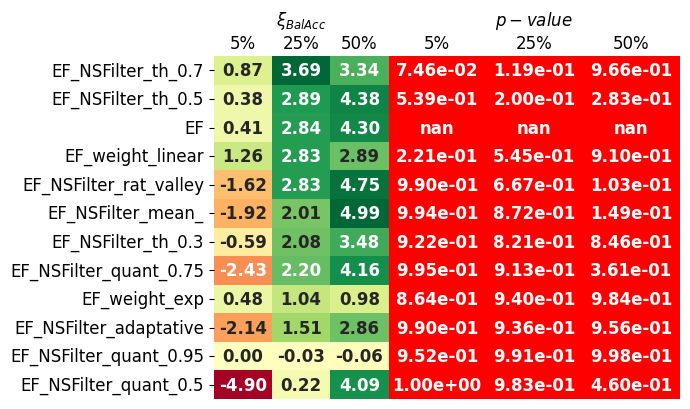

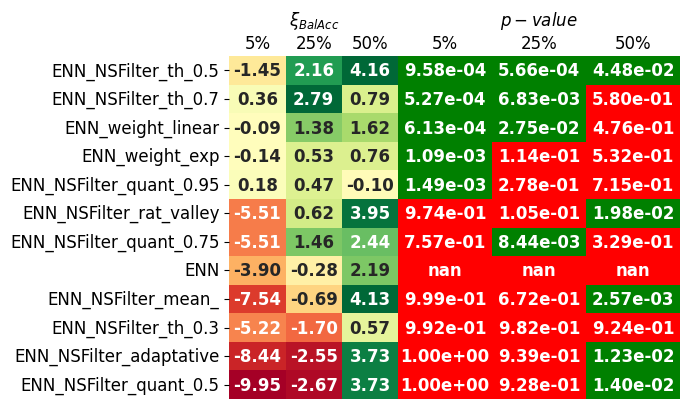

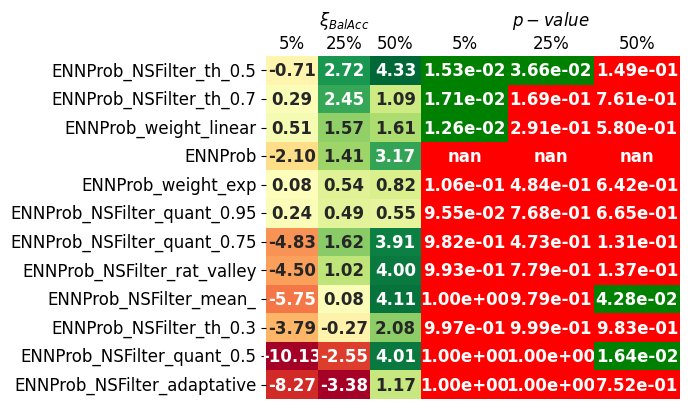

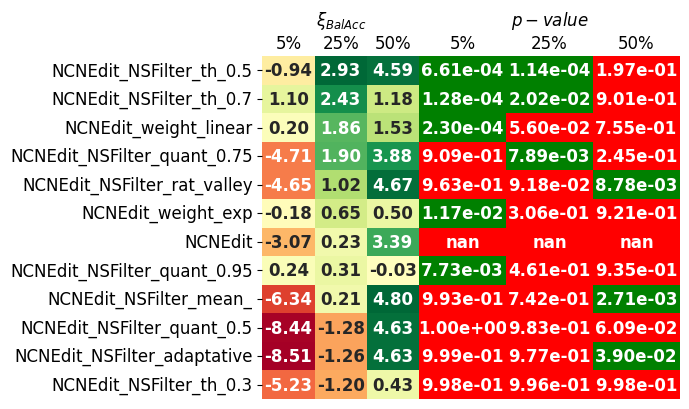

In [169]:
noise_levels = [5, 25, 50]

for bf, tabla in tablas.items():
    diff = tabla["bal_acc_diff"].copy()
    pval = tabla["p_value"].copy()

    fig, axes = plt.subplots(1, 6, figsize=(7, max(4, 0.35 * len(tabla))),
    gridspec_kw={"width_ratios": 3*[0.6]+[ 1, 1, 1], "wspace": 0.}
    )

    for i, nk in enumerate(noise_levels):
        sns.heatmap(
            diff[[nk]],
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            cbar=False,
            ax=axes[i],
            annot_kws={"size": 12, "weight":600},
        )
        if i==1:
            axes[i].set_title(r"$\xi_{BalAcc}$"+f"\n{nk}%")
        else:
            axes[i].set_title(f"{nk}%")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="y", rotation=0, labelsize=12)
        axes[i].set_xticks([])
        if i!=0:
         axes[i].set_yticks([])

    for i, nk in enumerate(noise_levels):
        sig = (pval[[nk]] < 0.05).astype(int)
        sns.heatmap(
            sig,
            annot=pval[[nk]],
            fmt=".2e",
            cmap=sns.color_palette(["red", "green"], as_cmap=True),
            vmin=0,
            vmax=1,
            cbar=False,
            ax=axes[i + 3],
            annot_kws={"size": 12, "weight":600},
        )
        if i==1:
            axes[i+3].set_title(r"$p-value$"+f"\n{nk}%")
        else:
            axes[i+3].set_title(f"{nk}%")
        axes[i + 3].set_xlabel("")
        axes[i + 3].set_ylabel("")
        axes[i + 3].set_yticks([])
        axes[i+3].set_xticks([])

    plt.tight_layout()
    plt.savefig(base_path + f"/img/noiseScoringApproach/{bf}.png")
    plt.show()

In [130]:
res

,dataset_id,filter_id,noise_k,bal_acc,baseline_bal_acc,bal_acc_diff,base_filter
0,autos,EF,5,0.601630,0.706000,-10.437037,EF
1,autos,EF,25,0.473926,0.651370,-17.744444,EF
2,autos,EF,50,0.401852,0.461852,-6.000000,EF
3,autos,EF_NSFilter_adaptative,5,0.467704,0.706000,-23.829630,EF
4,autos,EF_NSFilter_adaptative,25,0.418741,0.651370,-23.262963,EF
...,...,...,...,...,...,...,...
4405,zoo,NCNEdit_weight_linear,25,0.740476,0.698214,4.226190,NCNEdit
4406,zoo,NCNEdit_weight_linear,50,0.706349,0.651389,5.496032,NCNEdit
4407,zoo,None,5,0.858730,0.858730,0.000000,None
4408,zoo,None,25,0.698214,0.698214,0.000000,None


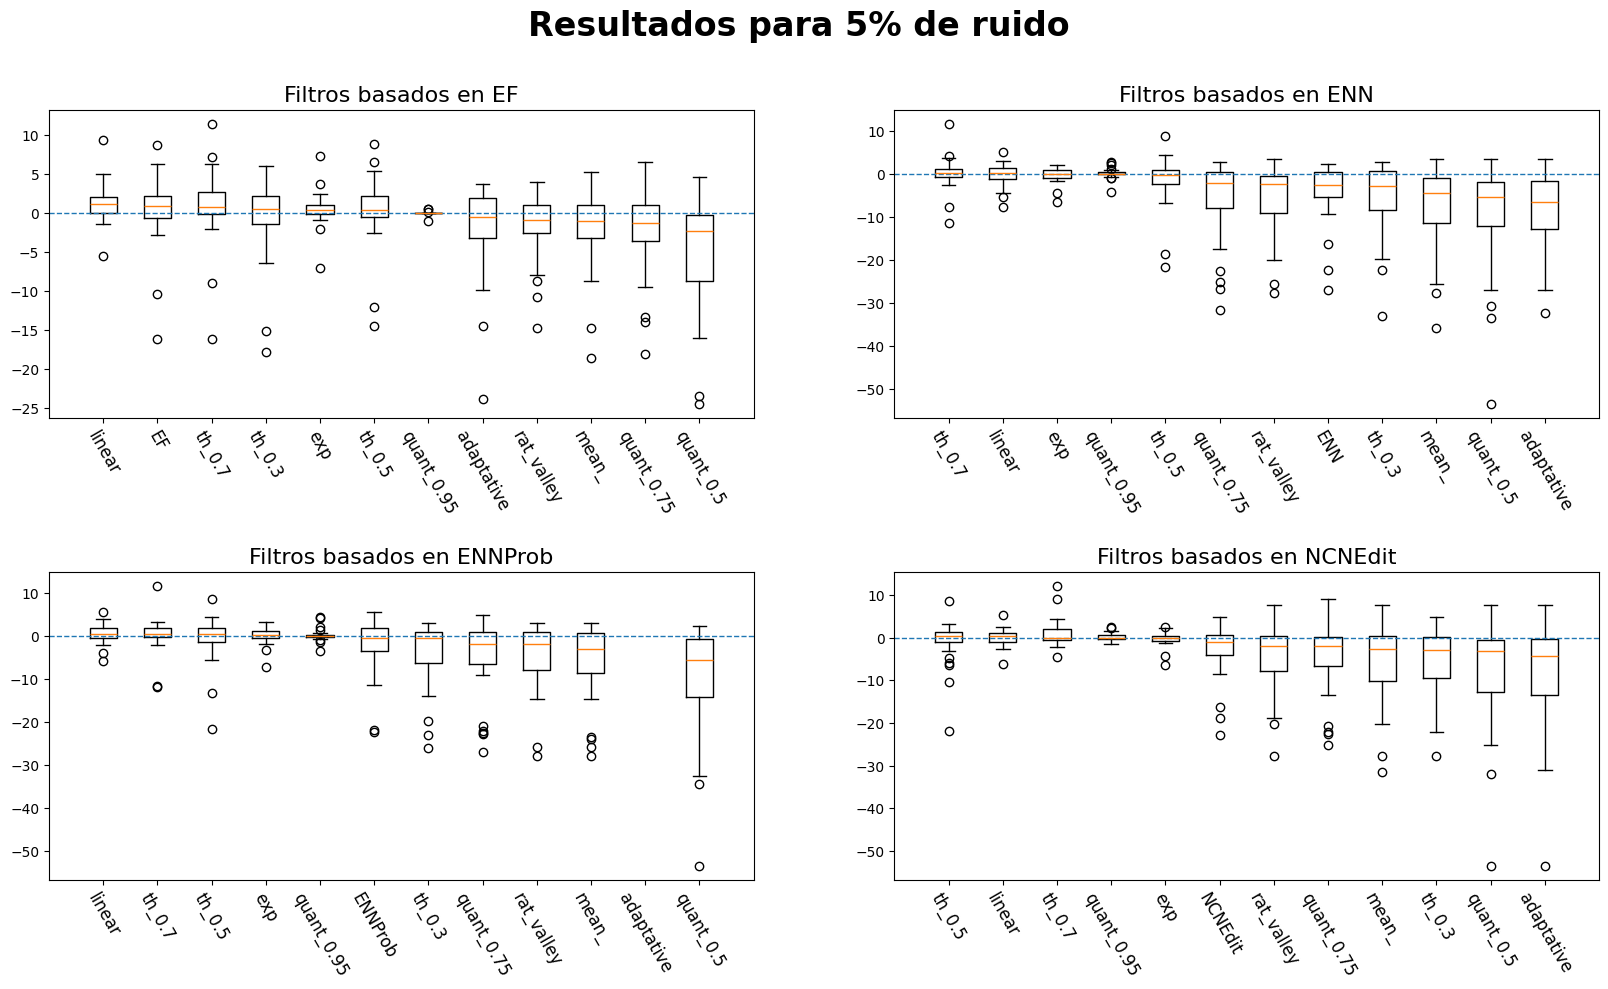

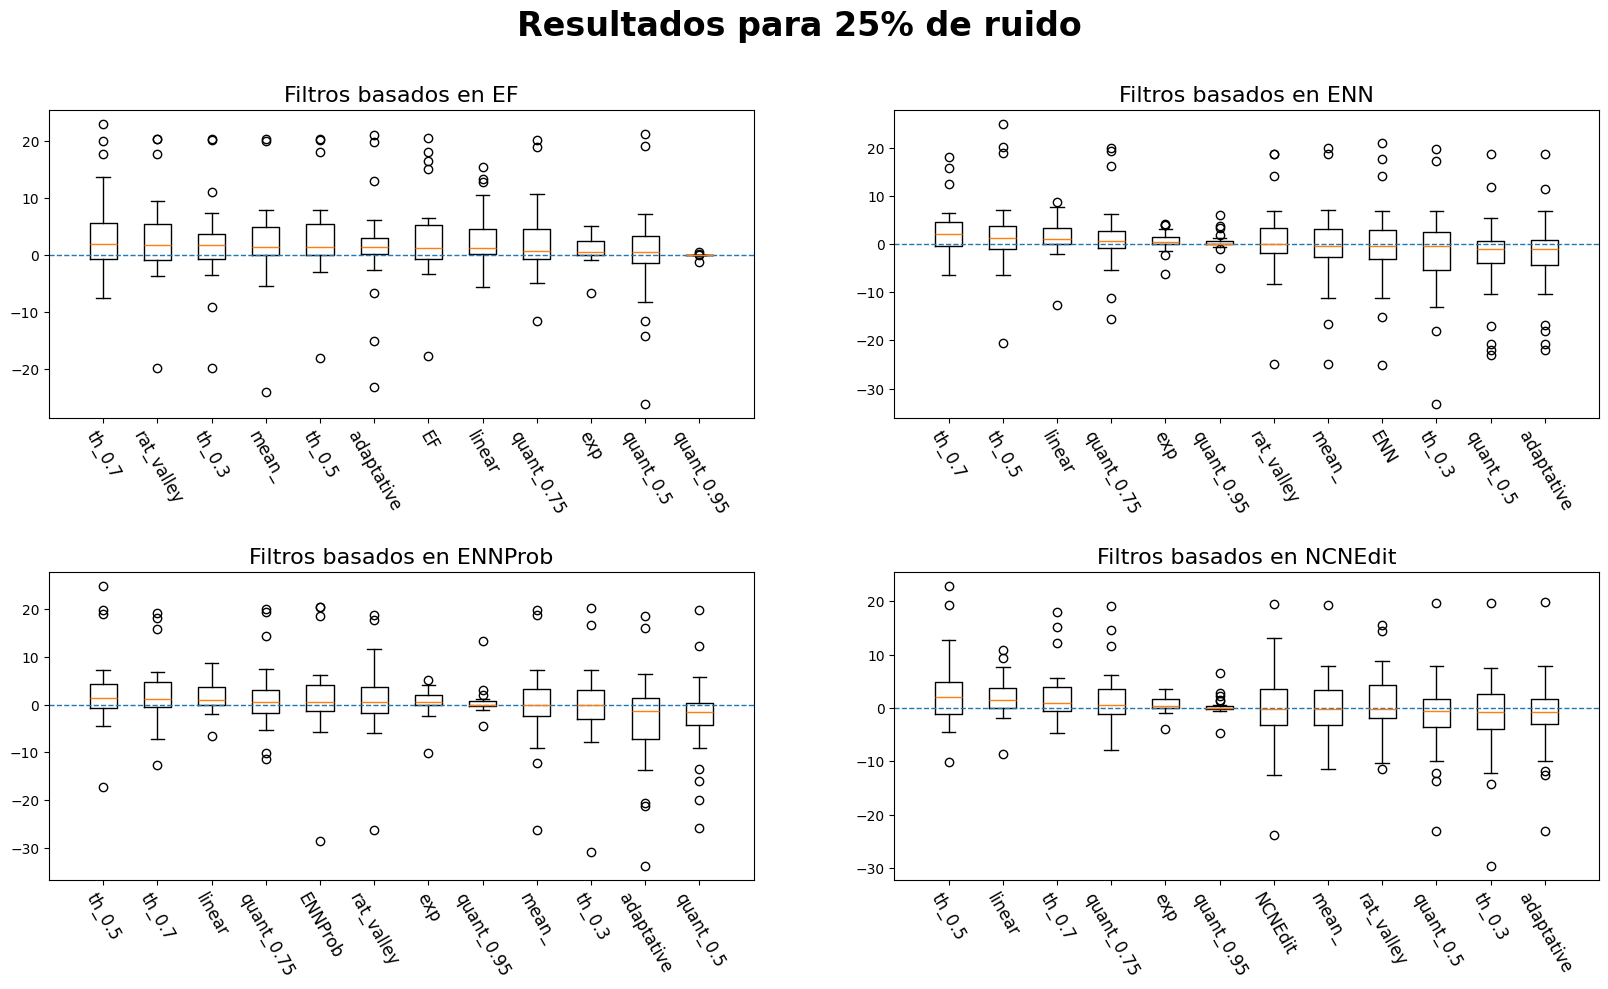

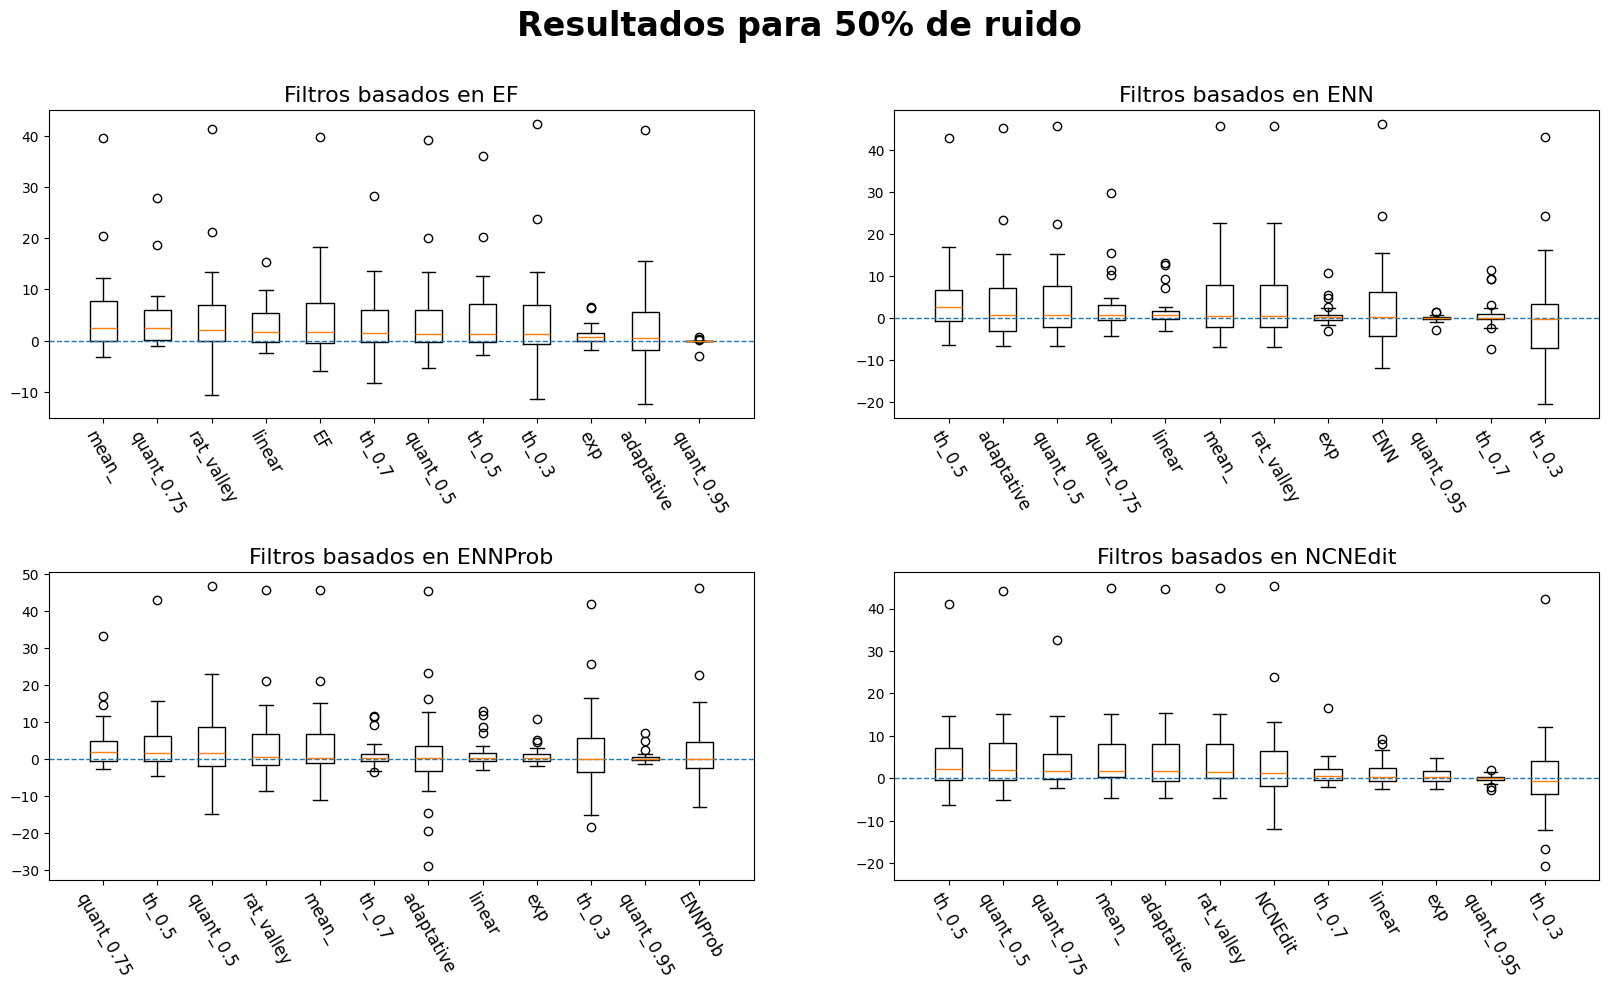

In [178]:
for noise_k in [5, 25, 50]:
    plt.figure(figsize=(20,10))
    for i, (bf, g) in enumerate(res[res.noise_k==noise_k].groupby("base_filter")):
        if bf!="None":
            plt.subplot(2,2,1+i)
            order = (
                g.groupby("filter_id")["bal_acc_diff"]
                .median()
                .sort_values(ascending=False)
                .index
            )

            data = [g.loc[g["filter_id"] == fid, "bal_acc_diff"] for fid in order]

            plt.boxplot(data)

            plt.title(f"Filtros basados en {bf}", fontsize=16)
            labels = [
                (fid if fid == bf else "_".join(fid.split("_")[2:]))
                for fid in order
            ]
            plt.xticks(np.arange(1, 1 + len(labels)), labels=labels, rotation=-60, fontsize=12)
            plt.hlines([0], xmin=0, xmax=len(labels) + 1, lw=1, ls="--")
            plt.xlim(0, len(labels) + 1)
            plt.subplots_adjust(hspace=0.5)
    plt.suptitle(f"Resultados para {noise_k}% de ruido", fontsize=24, fontweight=600)
    plt.savefig(base_path+f"/img/noiseScoringApproach/{noise_k}_boxplot.png")
    plt.show()

In [205]:
v = []
for ds_id,g in res[(res.filter_id.isin(["EF", "EF_NSFilter_th_0.7"]))&(res.noise_k==5)][["dataset_id","bal_acc"]].groupby("dataset_id"):
    e = g.bal_acc.values[1]-g.bal_acc.values[0]
    v.append(e)
    print(e)
wilcoxon(v, alternative="greater").pvalue

0.014592592592592601
-0.003428110506150439
0.027168704501240537
0.05495021645021647
0.0012264431060956538
0.007407407407407418
0.006924114473375598
0.007080036875409146
0.0023809523809523725
0.03039682539682531
0.018989898989899
0.0
0.0
0.0
-0.014538961038961018
0.0
0.0
0.0
0.029233841684822126
-0.003816911250873467
0.0025974025974025983
0.00014705882352938904
0.0
-0.016818181818181843
0.0014479512735326994
-0.002020202020201922
0.0
0.0
-0.013153100243178062
-0.014285714285714235


np.float64(0.07458879453142199)